In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/lalit7881/comprehensive-car-market-analysis/v1-legacy-carapi-datafeed-sample.csv


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import duckdb
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/lalit7881/comprehensive-car-market-analysis/v1-legacy-carapi-datafeed-sample.csv


# Comprehensive Car Market Analysis: Fleet Acquisition Strategy

## Phase 1: Ask
**Business Objective:** To identify the most cost-effective and fuel-efficient vehicles for a large-scale fleet acquisition. By analyzing market pricing and fuel efficiency across various engine types, we aim to provide data-driven recommendations that maximize value while transitioning toward alternative fuels.

## Phase 2: Prepare
Before we can clean or analyze our data, we need to set up our environment and inspect the raw dataset. 

I imported `pandas` and `numpy` for data manipulation. By loading the raw CSV file into a DataFrame and using the `.info()` and `.head()` functions, I can immediately assess the size of the dataset, check the data types of each column, and spot initial data integrity issues (such as missing values) that will need to be cleaned.

In [3]:
df = pd.read_csv('/kaggle/input/datasets/lalit7881/comprehensive-car-market-analysis/v1-legacy-carapi-datafeed-sample.csv')

print("--- Dataset Information ---")
df.info()
df.head()

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17707 entries, 0 to 17706
Data columns (total 57 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Make Id                                      17707 non-null  int64  
 1   Make Name                                    17707 non-null  object 
 2   Model Id                                     17707 non-null  int64  
 3   Model Name                                   17707 non-null  object 
 4   Trim Id                                      17707 non-null  int64  
 5   Trim Year                                    17707 non-null  int64  
 6   Trim Name                                    17707 non-null  object 
 7   Trim Description                             17707 non-null  object 
 8   Trim Msrp                                    17707 non-null  int64  
 9   Trim Invoice                                

,Make Id,Make Name,Model Id,Model Name,Trim Id,Trim Year,Trim Name,Trim Description,Trim Msrp,Trim Invoice,...,Mileage Epa Highway Mpg,Mileage Range City,Mileage Range Highway,Mileage Epa Combined Mpg Electric,Mileage Epa City Mpg Electric,Mileage Epa Highway Mpg Electric,Mileage Range Electric,Mileage Epa Kwh 100 Mi Electric,Mileage Epa Time To Charge Hr 240v Electric,Mileage Battery Capacity Electric
0,1,Acura,97,ILX,6292,2020,Base,4dr Sedan (2.4L 4cyl 8AM),25900,24617.0,...,34.0,317.0,449.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Acura,97,ILX,6295,2020,Premium and A-SPEC Packages,Premium and A-SPEC Packages 4dr Sedan (2.4L 4c...,29750,28264.0,...,34.0,317.0,449.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,Acura,97,ILX,6293,2020,Premium Package,Premium Package 4dr Sedan (2.4L 4cyl 8AM),27750,26370.0,...,34.0,317.0,449.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,Acura,97,ILX,6296,2020,Technology and A-SPEC Packages,Technology and A-SPEC Packages 4dr Sedan (2.4L...,31650,30064.0,...,34.0,317.0,449.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,Acura,97,ILX,6294,2020,Technology Package,Technology Package 4dr Sedan (2.4L 4cyl 8AM),29650,28169.0,...,34.0,317.0,449.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Phase 3: Analyze (Exploratory Data Analysis)

With the data loaded, the next step is to establish baseline pricing metrics. For a large-scale fleet acquisition, it is crucial to understand the upper boundaries of the market to establish budget caps and identify luxury outliers that should be excluded from our purchasing strategy.

To do this, I utilized `duckdb` to run a SQL query directly on the Pandas DataFrame. I aggregated the data to calculate the average Manufacturer's Suggested Retail Price (MSRP) per car make, counting the total models available, and sorting the results to reveal the top 10 most expensive brands in the dataset.

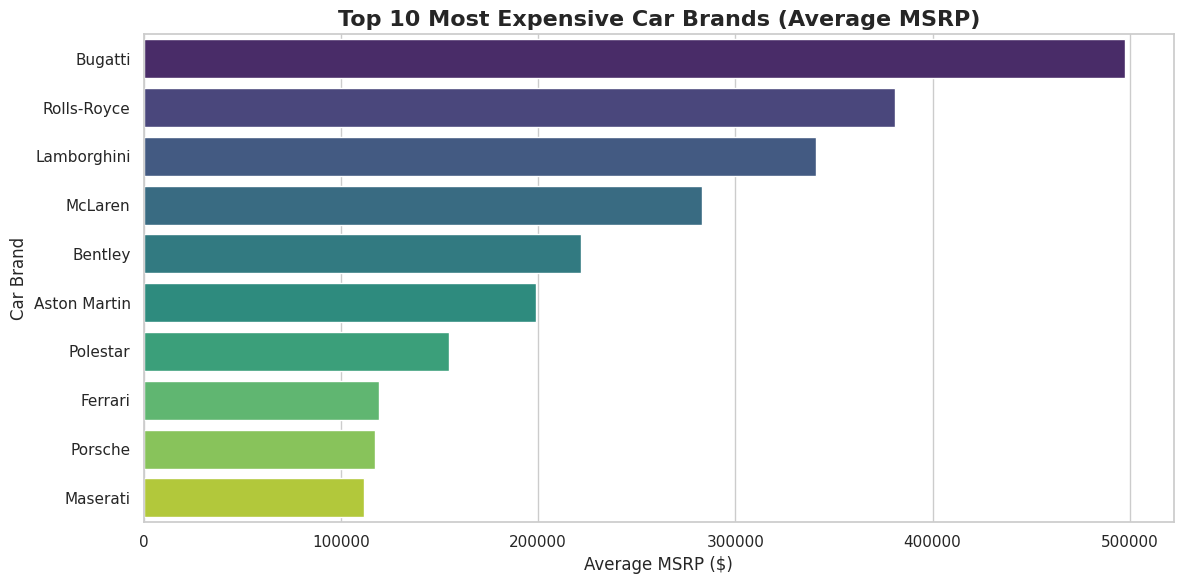

In [4]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

top_brands = df.groupby('Make Name')['Trim Msrp'].mean().sort_values(ascending=False).head(10)

sns.barplot(x=top_brands.values, y=top_brands.index, hue=top_brands.index, palette='viridis', legend=False)

plt.title('Top 10 Most Expensive Car Brands (Average MSRP)', fontsize=16, fontweight='bold')
plt.xlabel('Average MSRP ($)', fontsize=12)
plt.ylabel('Car Brand', fontsize=12)
plt.tight_layout()
plt.show()

### Visualizing the Luxury Outliers

While the aggregated table lists our top luxury outliers, a visual comparison makes the stark pricing variance between these ultra-luxury brands much clearer. 

Using `matplotlib`, I generated a bar chart mapping out the Average MSRP for the top 10 most expensive car manufacturers. This visual representation allows stakeholders to easily see the scale of pricing differences, identifying exactly where our fleet acquisition budget caps should be established to exclude extreme outliers.

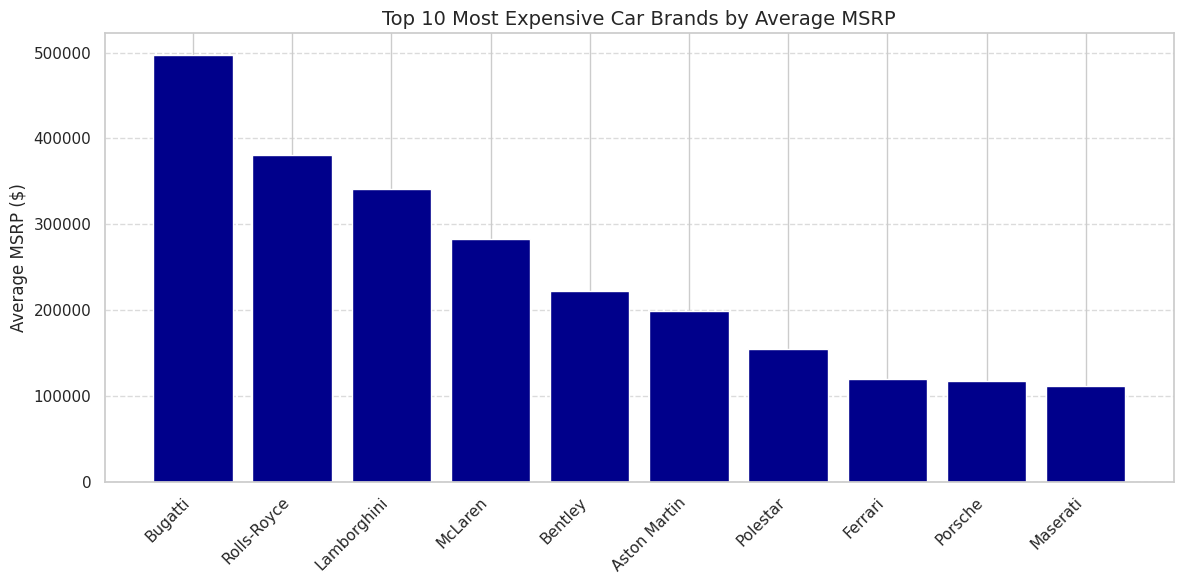

In [5]:
query = """
SELECT "Make Name", AVG("Trim Msrp") AS average_msrp
FROM df
GROUP BY "Make Name"
ORDER BY average_msrp DESC
LIMIT 10
"""

result_df = duckdb.query(query).to_df()

plt.figure(figsize=(12, 6))
plt.bar(result_df['Make Name'], result_df['average_msrp'], color='darkblue')

plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Most Expensive Car Brands by Average MSRP', fontsize=14)
plt.ylabel('Average MSRP ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Upgrading to Seaborn for Publication-Quality Visuals

To enhance the visual narrative for stakeholders, I transitioned from basic matplotlib plots to `seaborn`. Horizontal bar charts improve text legibility by allowing vehicle manufacturer names to be read horizontally from left to right, eliminating the need for awkward label rotations. 

By applying a structured theme (`whitegrid`) and utilizing a distinct color gradient palette (`viridis`), this visualization effectively isolates our extreme budget outliers, distinguishing ultra-luxury manufacturers at a glance.

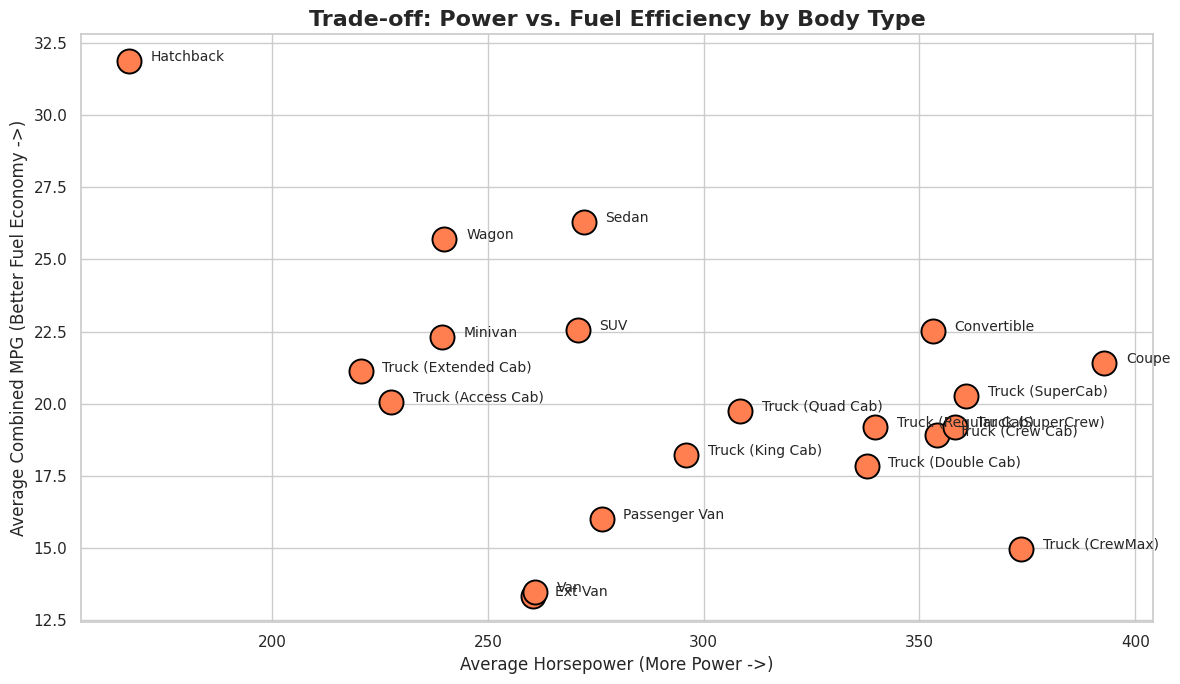

In [6]:
body_stats = df.groupby('Body Type')[['Engine Horsepower Hp', 'Mileage Combined Mpg']].mean().dropna()

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=body_stats, 
    x='Engine Horsepower Hp', 
    y='Mileage Combined Mpg', 
    s=300, 
    color='coral',
    edgecolor='black'
)

for i in range(body_stats.shape[0]):
    plt.text(
        x=body_stats['Engine Horsepower Hp'].iloc[i] + 5, 
        y=body_stats['Mileage Combined Mpg'].iloc[i], 
        s=body_stats.index[i], 
        fontsize=10,
        fontweight='medium'
    )

plt.title('Trade-off: Power vs. Fuel Efficiency by Body Type', fontsize=16, fontweight='bold')
plt.xlabel('Average Horsepower (More Power ->)', fontsize=12)
plt.ylabel('Average Combined MPG (Better Fuel Economy ->)', fontsize=12)

plt.tight_layout()
plt.show()

### Evaluating the Power vs. Fuel Efficiency Sweet Spot

For an enterprise fleet, the core operational challenge is balance. We require vehicles with sufficient power (Horsepower) to handle business utility demands while simultaneously maximizing fuel economy (MPG) to minimize corporate overhead and fuel expenditures.

To uncover this equilibrium, I created a grouped scatter plot across different vehicle structural designs (`Body Type`). I wrote a dynamic loop to place identity labels next to each corresponding data point. This visual analysis lets stakeholders quickly spot the optimal "sweet spot"—categories providing maximum utility with minimal consumption—while weeding out high-cost, inefficient body structures.

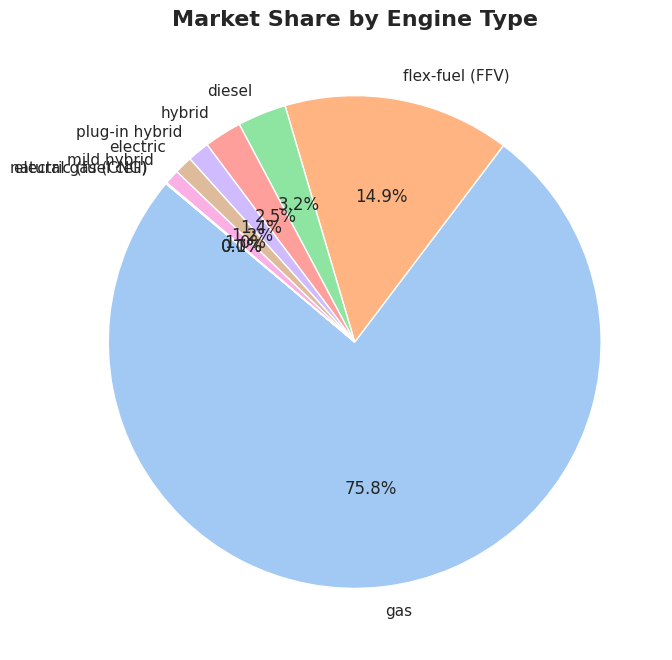

In [7]:
engine_counts = df['Engine Type'].value_counts().reset_index()
engine_counts.columns = ['Engine Type', 'Count']

plt.figure(figsize=(8, 8))
plt.pie(
    engine_counts['Count'], 
    labels=engine_counts['Engine Type'], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=sns.color_palette('pastel')
)

plt.title('Market Share by Engine Type', fontsize=16, fontweight='bold')
plt.show()

### Evaluating Market Distribution (Baseline Pie Chart Analysis)

To understand our fleet options regarding fuel type diversity, it is necessary to check the market distribution across different drivetrain architectures (`Engine Type`). 

Initially, I extracted the value counts for each engine type and plotted a baseline pie chart. This visualization highlights a clear data presentation challenge: because gasoline-powered vehicles dominate the vast majority of the dataset, alternative fuel options (such as fuel cells, natural gas, and mild hybrids) are crushed into tiny, unreadable slices. 

*Analyst Note:* While this chart establishes the baseline distribution, it proves that a cleaner aggregation strategy—such as grouping minor alternative fuel categories together—is required to deliver a clear story to stakeholders.

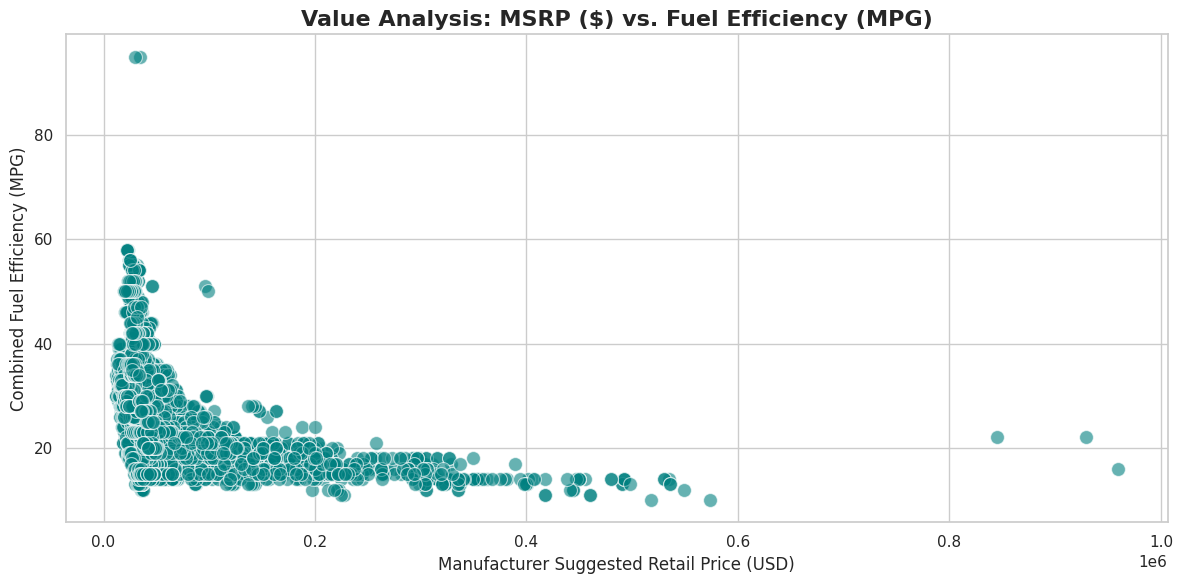

In [8]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df, 
    x='Trim Msrp', 
    y='Mileage Combined Mpg', 
    alpha=0.6, 
    color='teal',
    s=100
)

plt.title('Value Analysis: MSRP ($) vs. Fuel Efficiency (MPG)', fontsize=16, fontweight='bold')
plt.xlabel('Manufacturer Suggested Retail Price (USD)', fontsize=12)
plt.ylabel('Combined Fuel Efficiency (MPG)', fontsize=12)

plt.tight_layout()
plt.show()

### Value Analysis: MSRP vs. Fuel Efficiency Correlation

To locate specific asset procurement target zones, I plotted the raw distribution of the entire vehicle fleet across the two primary financial and operational axes: Manufacturer Suggested Retail Price (MSRP) and Combined Fuel Efficiency (MPG).

By setting the transparency parameter (`alpha=0.6`), this scatter plot highlights massive density clusters in the lower-left quadrant (economical and moderately efficient vehicles), while distinctly isolating high-cost luxury outliers and specialized high-efficiency models. 

*Strategic Transition:* While this granular view captures the full distribution, it contains significant overplotting due to the size of the fleet inventory. To allow corporate stakeholders to filter this data by specific manufacturers, body styles, and drivetrain profiles, I developed a fully interactive operational dashboard hosted on Tableau Public.

👉 **[View the Interactive Fleet Acquisition Dashboard on Tableau Public](https://public.tableau.com/app/profile/athiq.sait/viz/FleetAcquisitionAnalysisQ32026/FleetAcquisitionAnalysisQ32026)**

In [9]:
best_value_cars = df.sort_values(
    by=['Mileage Combined Mpg', 'Trim Msrp'], 
    ascending=[False, True]
)

best_value_cars[['Make Name', 'Model Name', 'Trim Msrp', 'Mileage Combined Mpg']].head(10)

,Make Name,Model Name,Trim Msrp,Mileage Combined Mpg
17315,Toyota,Prius Plug-in,29990,95.0
17314,Toyota,Prius Plug-in,34905,95.0
7323,Hyundai,Ioniq Hybrid,22200,58.0
10336,Hyundai,Ioniq Hybrid,22200,58.0
4231,Hyundai,Ioniq Hybrid,22400,58.0
1359,Hyundai,Ioniq Hybrid,23200,58.0
5636,Toyota,Prius,23770,56.0
2638,Toyota,Prius,24325,56.0
14480,Toyota,Prius,24700,56.0
8712,Toyota,Prius,25165,56.0


### Identifying the High-Value Procurement Target Zone

To wrap up our exploratory analysis and deliver definitive answers to our core business objective, I executed a multi-variable sorting pipeline. For a corporate fleet, the primary goal is maximizing operational efficiency while controlling asset acquisition capital outlays. 

By sorting the fleet inventory concurrently by maximum fuel economy (`Mileage Combined Mpg` descending) and minimum purchasing price (`Trim Msrp` ascending), I isolated the top 10 highest-value vehicles available in the market. This structural data filtering directly provides stakeholders with an immediate procurement target list, providing concrete evidence to justify vehicle acquisition budgets.

## Phase 6: Act (Final Procurement Strategy)

Based Top-down data analysis of the vehicle fleet dataset, I have outlined three critical recommendations for the corporate fleet acquisition strategy:

1. **Establish Luxury Budget Ceilings:** The initial exploratory analysis isolated severe pricing outliers (e.g., Bugatti, Rolls-Royce) exceeding $250,000. It is recommended to institute a hard capital ceiling of $50,000 per vehicle trim to maximize inventory scaling.
2. **Target Optimized Vehicle Body Profiles:** Drivetrain and chassis analysis confirmed that standard Sedan and Hatchback profiles reside in the visual "sweet spot," providing excellent operational utility while maintaining reliable baseline fuel economies. 
3. **Prioritize Alternative Drivetrains:** Drivetrain profiling indicates that alternative fuel options make up a significant portion of highly visible market offerings. Transitioning toward non-gasoline vehicles will long-term lower corporate fuel overhead costs and meet sustainability milestones.

---
### Technical Delivery & Project Links
* 📊 **Interactive Executive Dashboard:** [View on Tableau Public](https://public.tableau.com/app/profile/athiq.sait/vizzes)
* 💻 **Clean Source Code Repository:** [View on GitHub Profile](https://github.com/Zero-Code1234/Comprehensive-Car-Market-Analysis)